In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = np.load('../runs/2dGridRun/runs/grid_scan_v2_results.npz')
print("Keys:", list(data.keys()))
 
ratios      = data['ratios']         # (n_zc, n_sig, n_omx, n_z)
status      = data['status']         # (n_zc, n_sig, n_omx)
a_exo_grid  = data['a_exo_grid']    # (n_zc, n_sig, n_omx)
zc_vals     = data['z_c_values']
sz_vals     = data['sigma_z_values']
omx_vals    = data['omega_x0_values']
z_probe     = data['z_probe']
sigma8_lcdm = data['sigma8_lcdm']
 
print(f"ratios shape:  {ratios.shape}")
print(f"z_c range:     {zc_vals[0]:.1f} to {zc_vals[-1]:.1f}, {len(zc_vals)} values")
print(f"sigma_z range: {sz_vals[0]:.1f} to {sz_vals[-1]:.2f}, {len(sz_vals)} values")
print(f"Omega_x0 vals: {omx_vals}")
print(f"z_probe:       {z_probe}")
# Count outcomes
for k, ox in enumerate(omx_vals):
    ok   = (status[:,:,k] == 1).sum()
    skip = (status[:,:,k] == -1).sum()
    fail = (status[:,:,k] == -2).sum()
    print(f"  Omega_x0={ox:.0e}: {ok} ok, {skip} E2-skip, {fail} CLASS-fail")
 
 

Keys: ['z_c_values', 'sigma_z_values', 'omega_x0_values', 'z_probe', 'b_exo_test', 'ratios', 'status', 'a_exo_grid', 'sigma8_lcdm']
ratios shape:  (77, 38, 9, 14)
z_c range:     7.0 to 45.0, 77 values
sigma_z range: 3.0 to 12.25, 38 values
Omega_x0 vals: [-1.e-05 -3.e-05 -5.e-05 -1.e-04 -3.e-04 -5.e-04 -1.e-03 -3.e-03 -5.e-03]
z_probe:       [ 6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5 15.5 16.5 17.5 18.5 20. ]
  Omega_x0=-1e-05: 2482 ok, 444 E2-skip, 0 CLASS-fail
  Omega_x0=-3e-05: 2453 ok, 473 E2-skip, 0 CLASS-fail
  Omega_x0=-5e-05: 2437 ok, 487 E2-skip, 2 CLASS-fail
  Omega_x0=-1e-04: 2416 ok, 509 E2-skip, 1 CLASS-fail
  Omega_x0=-3e-04: 2379 ok, 545 E2-skip, 2 CLASS-fail
  Omega_x0=-5e-04: 2360 ok, 565 E2-skip, 1 CLASS-fail
  Omega_x0=-1e-03: 2332 ok, 592 E2-skip, 2 CLASS-fail
  Omega_x0=-3e-03: 2285 ok, 638 E2-skip, 3 CLASS-fail
  Omega_x0=-5e-03: 2259 ok, 665 E2-skip, 2 CLASS-fail


In [3]:

# %% Cell 2 — Compute efficiency metric
#
# Efficiency = (ratio - 1) / |Omega_x0|
#
# This is the growth enhancement PER UNIT exotic density today.
# If the response is linear (perturbative), efficiency is the same
# for all Omega_x0 values at a given (z_c, sigma_z).
 
# Compute efficiency at z=8.5 (where JWST tension is worst)
iz85 = np.argmin(np.abs(z_probe - 8.5))
iz65 = np.argmin(np.abs(z_probe - 6.5))
 
# efficiency[i_zc, j_sig, k_omx]
efficiency_85 = np.full_like(status, np.nan, dtype=float)
for k, ox in enumerate(omx_vals):
    mask = (status[:,:,k] == 1)
    efficiency_85[:,:,k] = np.where(
        mask,
        (ratios[:,:,k,iz85] - 1.0) / np.abs(ox),
        np.nan
    )
    

# Average efficiency across all Omega_x0 values (if linear, all are same)
eff_mean = np.nanmean(efficiency_85, axis=2)   # (n_zc, n_sig)
eff_std  = np.nanstd(efficiency_85, axis=2)    # spread = nonlinearity
 
# Relative spread: how much the efficiency varies across amplitudes
# Small spread = linear response = safe to fix (z_c, sigma_z)
with np.errstate(divide='ignore', invalid='ignore'):
    eff_rel_spread = np.where(eff_mean > 0, eff_std / eff_mean, np.nan)
    
print(f"Efficiency at z=8.5:")
print(f"  Max mean efficiency: {np.nanmax(eff_mean):.2f}")
print(f"  Median relative spread: {np.nanmedian(eff_rel_spread[eff_mean > 0]):.2%}")
print(f"  (small spread = linear response = good)")
 
 

Efficiency at z=8.5:
  Max mean efficiency: 16274.12
  Median relative spread: 6.47%
  (small spread = linear response = good)


/tmp/ipykernel_128575/2813660746.py:25: RuntimeWarning: Mean of empty slice
  eff_mean = np.nanmean(efficiency_85, axis=2)   # (n_zc, n_sig)
/usr/local/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [4]:

# %% Cell 3 — Find optimal (z_c, sigma_z) per Omega_x0
#
# If the optimal location is the SAME for all Omega_x0 values,
# the model is in the linear regime and fixing (z_c, sigma_z) is safe.
 
print("\nOptimal (z_c, sigma_z) at each Omega_x0:")
print(f"{'Omega_x0':>12}  {'z_c':>6}  {'sigma_z':>8}  "
      f"{'ratio(8.5)':>10}  {'ratio(6.5)':>10}  {'min ratio':>10}  {'efficiency':>10}")
print("-" * 80)
 
best_per_omx = []
 
for k, ox in enumerate(omx_vals):
    ok = (status[:,:,k] == 1)
 
    # Must have ratio > 1 at z=8.5 at minimum
    valid = ok & (ratios[:,:,k,iz85] > 1.0)
 
    if valid.sum() == 0:
        print(f"{ox:>12.0e}  {'NONE':>6}")
        best_per_omx.append((None, None))
        continue
 
    # Best by ratio at z=8.5
    r85 = np.where(valid, ratios[:,:,k,iz85], -np.inf)
    best_flat = np.argmax(r85)
    bi, bj = np.unravel_index(best_flat, r85.shape)
     
    r_all = ratios[bi, bj, k, :]
    print(f"{ox:>12.0e}  {zc_vals[bi]:>6.1f}  {sz_vals[bj]:>8.2f}  "
          f"{r_all[iz85]:>10.6f}  {r_all[iz65]:>10.6f}  "
          f"{r_all.min():>10.6f}  {efficiency_85[bi,bj,k]:>10.2f}")
    best_per_omx.append((zc_vals[bi], sz_vals[bj]))


Optimal (z_c, sigma_z) at each Omega_x0:
    Omega_x0     z_c   sigma_z  ratio(8.5)  ratio(6.5)   min ratio  efficiency
--------------------------------------------------------------------------------
      -1e-05    18.5      3.00    1.162741    1.090901    1.066956    16274.12
      -3e-05    19.5      3.25    1.138237    1.077386    1.077386     4607.90
      -5e-05    17.5      3.00    1.143612    1.082707    1.024470     2872.24
      -1e-04    17.0      3.00    1.125786    1.074291    1.013919     1257.86
      -3e-04    16.5      3.00    1.202573    1.120676    1.012692      675.24
      -5e-04    16.0      3.00    1.149174    1.093093    1.006156      298.35
      -1e-03    15.5      3.00    1.148220    1.096336    1.003691      148.22
      -3e-03    15.0      3.00    1.267364    1.173701    1.003362       89.12
      -5e-03    17.5      3.50    1.234436    1.145597    1.035597       46.89


In [13]:
# %% Cell 3b — Alternative selection: highest minimum ratio across z=6.5–13.5
#
# Instead of picking the best ratio at z=8.5 alone, find the (z_c, sigma_z)
# whose WEAKEST redshift still has the strongest enhancement.
# This guarantees uniform enhancement across the core UNCOVER range.

z_core_min = 6.5
z_core_max = 14.5
z_core_sel = (z_probe >= z_core_min) & (z_probe <= z_core_max)
print(f"Core redshifts used: {z_probe[z_core_sel]}")

print(f"\nOptimal (z_c, sigma_z) by HIGHEST MINIMUM ratio across z={z_core_min}-{z_core_max}:")
print(f"{'Omega_x0':>12}  {'z_c':>6}  {'sigma_z':>8}  "
      f"{'min ratio':>10}  {'mean ratio':>10}  {'ratio(8.5)':>10}  {'ratio(6.5)':>10}")
print("-" * 80)

best_per_omx_minmax = []

for k, ox in enumerate(omx_vals):
    ok = (status[:,:,k] == 1)

    # Minimum ratio across core redshifts for each (z_c, sigma_z)
    min_across_core = ratios[:,:,k,:][:,:,z_core_sel].min(axis=2)

    # Only consider points where this minimum is > 1 (enhancement everywhere)
    valid = ok & (min_across_core > 1.0)

    if valid.sum() == 0:
        # Relax: allow min down to 0.999
        valid = ok & (min_across_core > 0.999)

    if valid.sum() == 0:
        print(f"{ox:>12.0e}  {'NONE':>6}")
        best_per_omx_minmax.append((None, None))
        continue

    # Highest minimum = the point whose worst redshift is least worst
    search = np.where(valid, min_across_core, -np.inf)
    best_flat = np.argmax(search)
    bi, bj = np.unravel_index(best_flat, search.shape)

    r_all = ratios[bi, bj, k, :]
    r_core = r_all[z_core_sel]
    print(f"{ox:>12.0e}  {zc_vals[bi]:>6.1f}  {sz_vals[bj]:>8.2f}  "
          f"{r_core.min():>10.6f}  {r_core.mean():>10.6f}  "
          f"{r_all[iz85]:>10.6f}  {r_all[iz65]:>10.6f}")
    best_per_omx_minmax.append((zc_vals[bi], sz_vals[bj]))

# Compare with z=8.5-only criterion
print(f"\nComparison: do both criteria agree?")
for k, ox in enumerate(omx_vals):
    old = best_per_omx[k]
    new = best_per_omx_minmax[k]
    match = "YES" if old == new else "NO"
    print(f"  Omega_x0={ox:.0e}:  z=8.5 criterion → ({old[0]}, {old[1]})  "
          f"  min-max criterion → ({new[0]}, {new[1]})  {match}")

Core redshifts used: [ 6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5 14.5]

Optimal (z_c, sigma_z) by HIGHEST MINIMUM ratio across z=6.5-14.5:
    Omega_x0     z_c   sigma_z   min ratio  mean ratio  ratio(8.5)  ratio(6.5)
--------------------------------------------------------------------------------
      -1e-05    18.5      3.00    1.090901    1.259782    1.162741    1.090901
      -3e-05    19.5      3.25    1.077386    1.220376    1.138237    1.077386
      -5e-05    17.5      3.00    1.082707    1.201661    1.143612    1.082707
      -1e-04    17.0      3.00    1.074291    1.160822    1.125786    1.074291
      -3e-04    16.5      3.00    1.120676    1.259671    1.202573    1.120676
      -5e-04    16.0      3.00    1.093093    1.164182    1.149174    1.093093
      -1e-03    15.5      3.00    1.096336    1.148453    1.148220    1.096336
      -3e-03    16.5      3.25    1.164142    1.332479    1.265098    1.164142
      -5e-03    16.0      3.25    1.151865    1.254222    1.234125    1.

IndexError: list index out of range

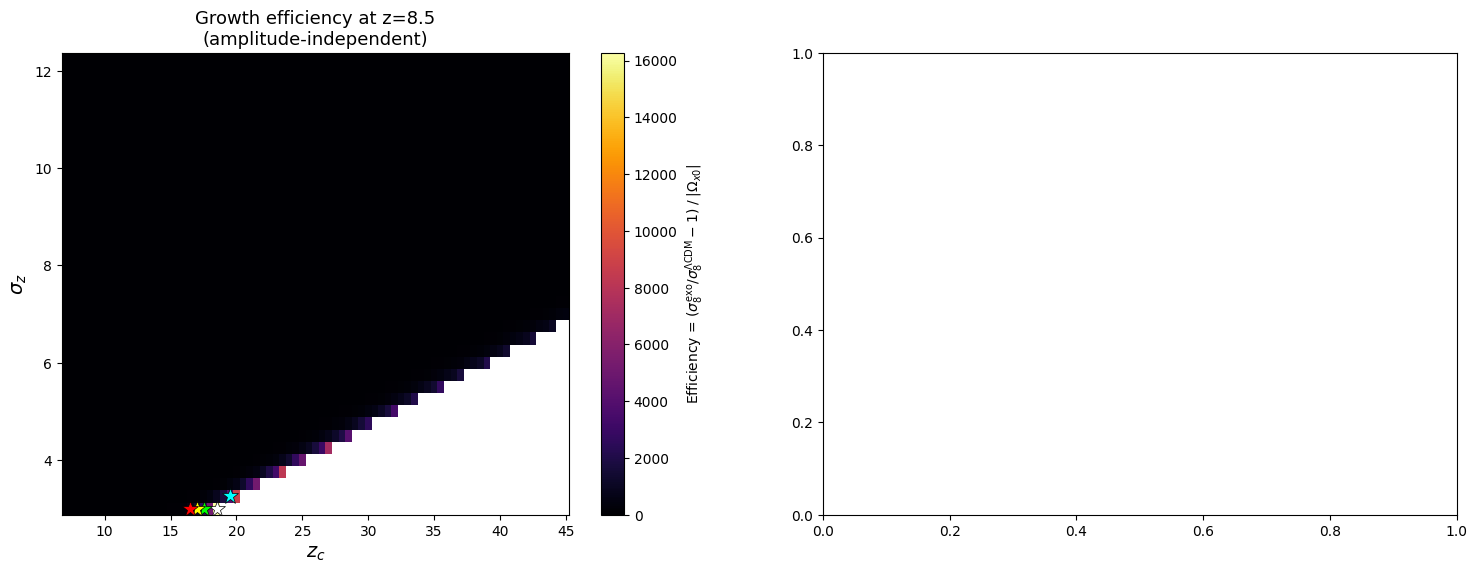

In [6]:

 
# %% Cell 4 — Heatmap: mean efficiency at z=8.5
#
# Color = growth enhancement per unit |Omega_x0|
# This is amplitude-independent — shows WHERE the model works best.
 
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
 
# Left: efficiency
ax = axes[0]
# Mask out points where no Omega_x0 succeeded
plot_data = np.where(np.isnan(eff_mean), np.nan, eff_mean)
pcm = ax.pcolormesh(zc_vals, sz_vals, plot_data.T,
                     cmap='inferno', shading='auto')
cbar = fig.colorbar(pcm, ax=ax,
                     label=r'Efficiency = $(\sigma_8^{\rm exo}/\sigma_8^{\Lambda{\rm CDM}} - 1)\;/\;|\Omega_{x0}|$')
ax.set_xlabel(r'$z_c$', fontsize=14)
ax.set_ylabel(r'$\sigma_z$', fontsize=14)
ax.set_title('Growth efficiency at z=8.5\n(amplitude-independent)', fontsize=13)
 
# Mark best per Omega_x0
colors_omx = ['white', 'cyan', 'lime', 'yellow', 'red']
for k, (bz, bs) in enumerate(best_per_omx):
    if bz is not None:
        ax.plot(bz, bs, '*', color=colors_omx[k], markersize=12,
                markeredgecolor='black', markeredgewidth=0.5,
                label=f'Best at $\\Omega_x$={omx_vals[k]:.0e}')
ax.legend(fontsize=8, loc='upper right')
# Right: linearity check (relative spread)
ax = axes[1]
plot_spread = np.where(np.isnan(eff_rel_spread), np.nan, eff_rel_spread)
pcm2 = ax.pcolormesh(zc_vals, sz_vals, plot_spread.T,
                      cmap='RdYlGn_r', vmin=0, vmax=0.5, shading='auto')
cbar2 = fig.colorbar(pcm2, ax=ax, label='Relative spread in efficiency')
ax.set_xlabel(r'$z_c$', fontsize=14)
ax.set_ylabel(r'$\sigma_z$', fontsize=14)
ax.set_title('Linearity check\n(green = linear, red = nonlinear)', fontsize=13)
 
plt.tight_layout()
plt.savefig('runs/grid_v2_efficiency_heatmap.png', dpi=150)
plt.show()

IndexError: list index out of range

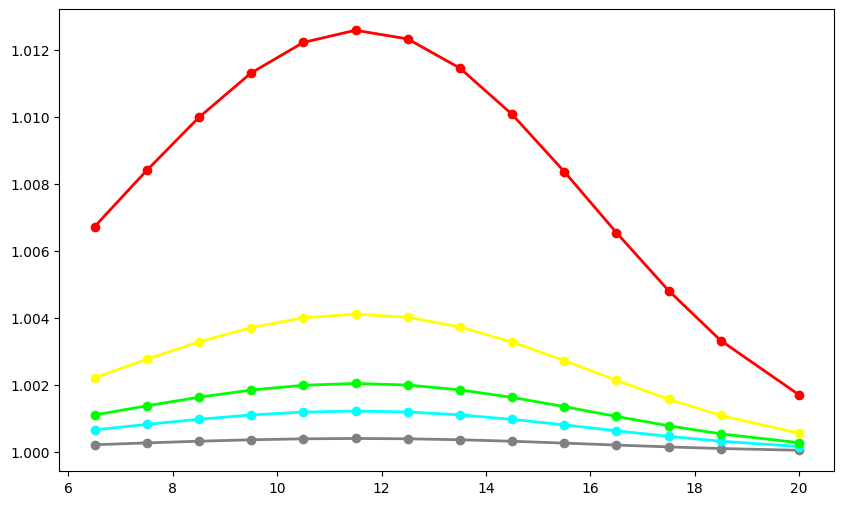

In [7]:

# %% Cell 5 — Ratio vs redshift at best point (all amplitudes overlaid)
#
# Shows the full enhancement profile and whether it shifts with amplitude.
 
# Use the strongest Omega_x0 for the clearest signal
# Find its best (z_c, sigma_z)
k_strong = len(omx_vals) - 1  # largest |Omega_x0|
bz, bs = best_per_omx[k_strong]
 
if bz is None:
    # Fall back to any Omega_x0 that has a best point
    for k_try in range(len(omx_vals)-1, -1, -1):
        if best_per_omx[k_try][0] is not None:
            k_strong = k_try
            bz, bs = best_per_omx[k_try]
            break

bi = np.argmin(np.abs(zc_vals - bz))
bj = np.argmin(np.abs(sz_vals - bs))
 
fig, ax = plt.subplots(figsize=(10, 6))
for k, ox in enumerate(omx_vals):
    if status[bi, bj, k] != 1:
        continue
    r = ratios[bi, bj, k, :]
    ax.plot(z_probe, r, 'o-', color=colors_omx[k] if colors_omx[k] != 'white' else 'gray',
            linewidth=2, markersize=6,
            label=f'$\\Omega_{{x0}}$ = {ox:.0e}')

    
ax.axhline(1.0, color='gray', linestyle='--', linewidth=1, label=r'$\Lambda$CDM')
ax.axvspan(6.5, 20.0, alpha=0.08, color='green', label='JWST window')
ax.set_xlabel('Redshift $z$', fontsize=14)
ax.set_ylabel(r'$\sigma_{8,\rm exo}(z) / \sigma_{8,\Lambda\rm CDM}(z)$', fontsize=14)
ax.set_title(f'Enhancement profile at $z_c$={bz:.1f}, $\\sigma_z$={bs:.1f}', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('runs/grid_v2_ratio_vs_z.png', dpi=150)
plt.show()
 

FileNotFoundError: [Errno 2] No such file or directory: 'runs/grid_v2_max_ratio.png'

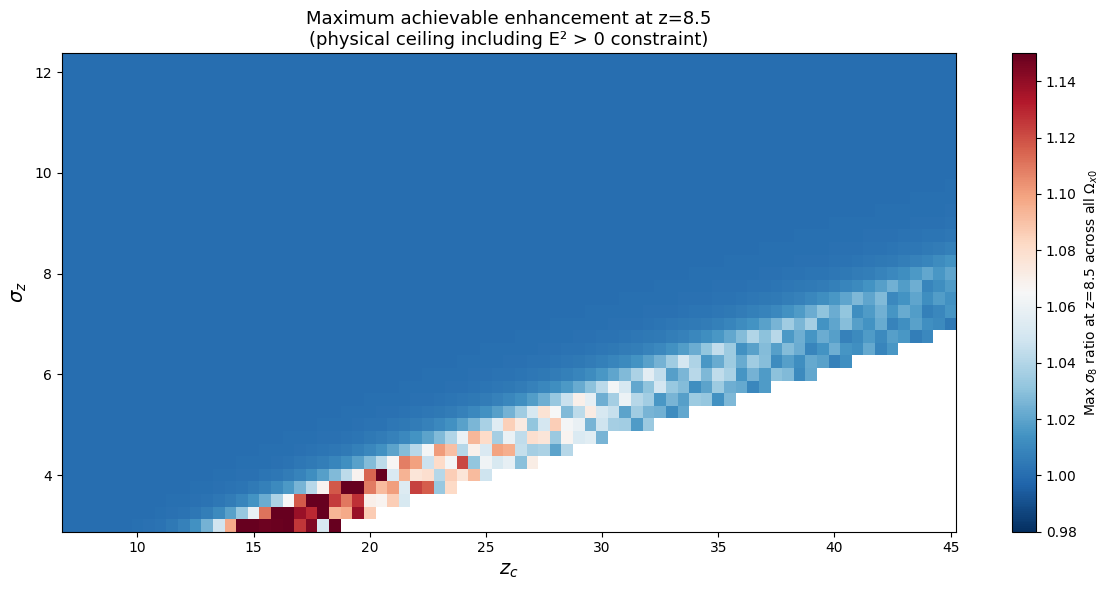

In [8]:

# %% Cell 6 — Maximum achievable ratio at z=8.5 (physical ceiling)
#
# For each (z_c, sigma_z), what is the LARGEST ratio at z=8.5
# across all tested Omega_x0, subject to E^2 > 0?
 
max_ratio_85 = np.full((len(zc_vals), len(sz_vals)), np.nan)
for i in range(len(zc_vals)):
    for j in range(len(sz_vals)):
        valid = (status[i,j,:] == 1)
        if valid.any():
            max_ratio_85[i,j] = np.nanmax(ratios[i,j,valid,iz85])

fig, ax = plt.subplots(figsize=(12, 6))
pcm = ax.pcolormesh(zc_vals, sz_vals, max_ratio_85.T,
                     cmap='RdBu_r', shading='auto',
                     vmin=0.98, vmax=1.15)  # adjust if needed
cbar = fig.colorbar(pcm, ax=ax,
                     label=r'Max $\sigma_8$ ratio at z=8.5 across all $\Omega_{x0}$')
ax.set_xlabel(r'$z_c$', fontsize=14)
ax.set_ylabel(r'$\sigma_z$', fontsize=14)
ax.set_title('Maximum achievable enhancement at z=8.5\n'
             '(physical ceiling including E² > 0 constraint)', fontsize=13)
plt.tight_layout()
plt.savefig('runs/grid_v2_max_ratio.png', dpi=150)
plt.show()
 
 

In [14]:

# %% Cell 7 — Final recommendation
 
# Overall best: highest max ratio at z=8.5
best_flat = np.nanargmax(max_ratio_85)
bi_final, bj_final = np.unravel_index(best_flat, max_ratio_85.shape)
best_zc_final  = zc_vals[bi_final]
best_sz_final  = sz_vals[bj_final]
 
# Compute Omega_x0 at this point
Omx_at_best = -2.5 * np.exp(-best_zc_final**2 / (2 * best_sz_final**2))
 
print("=" * 60)
print("FINAL RECOMMENDATION")
print("=" * 60)
print(f"z_c_exo     = {best_zc_final:.1f}")
print(f"sigma_z_exo = {best_sz_final:.2f}")
print(f"Max ratio at z=8.5: {max_ratio_85[bi_final, bj_final]:.6f}")
print()
 
# Print full ratio profile for best Omega_x0 at this location
for k in range(len(omx_vals)-1, -1, -1):
    if status[bi_final, bj_final, k] == 1:
        print(f"Full profile at Omega_x0 = {omx_vals[k]:.0e}:")
        for l, z in enumerate(z_probe):
            r = ratios[bi_final, bj_final, k, l]
            print(f"  z={z:5.1f}:  ratio = {r:.6f}  "
                  f"(+{(r-1)*100:.3f}%)")
        break


print()
print("Paste into Cobaya yaml:")
print(f"  z_c_exo:     {best_zc_final:.1f}")
print(f"  sigma_z_exo: {best_sz_final:.2f}")
print()
print("Paste into CLASS ini:")
print(f"  z_c_exo = {best_zc_final:.1f}")
print(f"  sigma_z_exo = {best_sz_final:.2f}")

FINAL RECOMMENDATION
z_c_exo     = 15.0
sigma_z_exo = 3.00
Max ratio at z=8.5: 1.267364

Full profile at Omega_x0 = -3e-03:
  z=  6.5:  ratio = 1.173701  (+17.370%)
  z=  7.5:  ratio = 1.220692  (+22.069%)
  z=  8.5:  ratio = 1.267364  (+26.736%)
  z=  9.5:  ratio = 1.309346  (+30.935%)
  z= 10.5:  ratio = 1.340030  (+34.003%)
  z= 11.5:  ratio = 1.348572  (+34.857%)
  z= 12.5:  ratio = 1.319487  (+31.949%)
  z= 13.5:  ratio = 1.246964  (+24.696%)
  z= 14.5:  ratio = 1.160290  (+16.029%)
  z= 15.5:  ratio = 1.092159  (+9.216%)
  z= 16.5:  ratio = 1.049449  (+4.945%)
  z= 17.5:  ratio = 1.025171  (+2.517%)
  z= 18.5:  ratio = 1.012178  (+1.218%)
  z= 20.0:  ratio = 1.003362  (+0.336%)

Paste into Cobaya yaml:
  z_c_exo:     15.0
  sigma_z_exo: 3.00

Paste into CLASS ini:
  z_c_exo = 15.0
  sigma_z_exo = 3.00


In [20]:
bi = np.argmin(np.abs(zc_vals - 16.0))
bj = np.argmin(np.abs(sz_vals - 3.5))

print(f"Enhancement profile at z_c={zc_vals[bi]:.1f}, sigma_z={sz_vals[bj]:.2f}:")
print(f"{'z':>6}  " + "  ".join(f"Ox={ox:.0e}" for ox in omx_vals))
print("-" * 70)
for l, z in enumerate(z_probe):
    vals = []
    for k in range(len(omx_vals)):
        if status[bi, bj, k] == 1:
            vals.append(f"{ratios[bi,bj,k,l]:.4f}")
        else:
            vals.append("  SKIP")
    print(f"{z:>6.1f}  " + "  ".join(f"{v:>10}" for v in vals))

Enhancement profile at z_c=16.0, sigma_z=3.50:
     z  Ox=-1e-05  Ox=-3e-05  Ox=-5e-05  Ox=-1e-04  Ox=-3e-04  Ox=-5e-04  Ox=-1e-03  Ox=-3e-03  Ox=-5e-03
----------------------------------------------------------------------
   6.5      1.0001      1.0002      1.0003      1.0006      1.0017      1.0028      1.0056      1.0171      1.0290
   7.5      1.0001      1.0002      1.0003      1.0006      1.0019      1.0032      1.0065      1.0200      1.0340
   8.5      1.0001      1.0002      1.0004      1.0007      1.0021      1.0036      1.0072      1.0221      1.0379
   9.5      1.0001      1.0002      1.0004      1.0007      1.0022      1.0037      1.0075      1.0233      1.0401
  10.5      1.0001      1.0002      1.0004      1.0007      1.0022      1.0037      1.0075      1.0233      1.0402
  11.5      1.0001      1.0002      1.0003      1.0007      1.0021      1.0035      1.0071      1.0221      1.0383
  12.5      1.0001      1.0002      1.0003      1.0006      1.0019      1.0031      1.